# Segmentation attempt
## Run on Dwarp

In [1]:
import pydicom
import numpy as np
import glob
import numpy
import os
#import scipy.ndimage       as nd
#from scipy.ndimage import zoom, generic_gradient_magnitude
from pathlib import Path
# import myVTKPythonLibrary as myvtk
# from pom_funkce_VTK import numpy2VTK
# from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from scipy import ndimage
import copy 
import skimage
from skimage import measure




base = "/Users/skardova/Documents/MRI_data/2026-Eyes-project/Trial2/"

src_folder = "DelRec - PDT1 0.5 Fat AIMax"
out_folder = "VTI_0.5_fat_AIMax"

img = numpy.load(base + out_folder + os.sep + "cut.npy")
img_shape = img.shape

print("img shape = ", img_shape)

factor = 2

img = ndimage.median_filter(img, size=2)
img = ndimage.zoom(img, 1/factor)

print("img shape = ", img.shape)



img shape =  (200, 170, 120)
img shape =  (100, 85, 60)


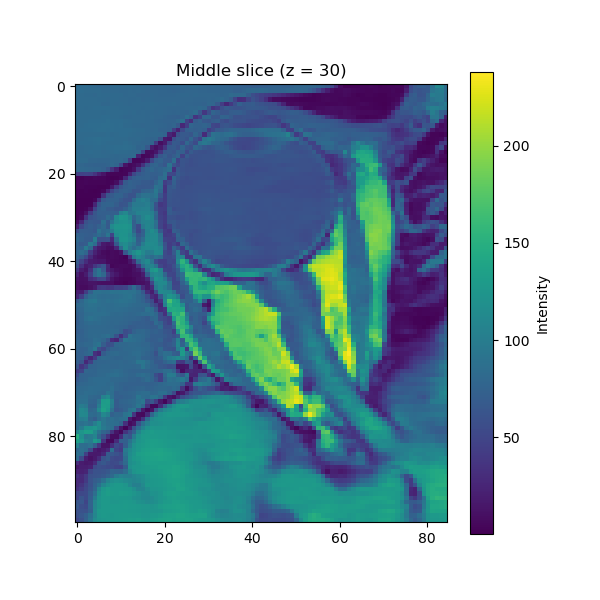

In [2]:
%matplotlib widget
import matplotlib.pyplot as plt

mid_z = img.shape[2] // 2

clicked_points = []  # ← stored here

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(img[:, :, mid_z], cmap="viridis")
ax.set_title(f"Middle slice (z = {mid_z})")

# add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Intensity")  # optional label

def onclick(event):
    if event.inaxes != ax:
        return

    x = int(round(event.xdata))
    y = int(round(event.ydata))

    if 0 <= y < img.shape[0] and 0 <= x < img.shape[1]:
        # point = (x, y, mid_z)
        point = (y, x, mid_z)   # row, col, z

        clicked_points.append(point)

        print(f"Stored click #{len(clicked_points)}: {point}")

        # optional: mark the point visually
        ax.plot(x, y, 'r+', markersize=10)
        fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()

In [13]:
def get_6_neighbors(coords, shape):
    """
    coords are (row, col, z)
    shape is img.shape = (rows, cols, depth)
    """
    neighbors = set()

    offsets = [(-1, 0, 0), (1, 0, 0),
               (0, -1, 0), (0, 1, 0),
               (0, 0, -1), (0, 0, 1)]

    nrows, ncols, nz = shape

    for r, c, z in coords:
        for dr, dc, dz in offsets:
            nr, nc, nz_ = r + dr, c + dc, z + dz
            if (1 <= nr < nrows-1 and
                1 <= nc < ncols-1 and
                1 <= nz_ < nz-1):
                neighbors.add((nr, nc, nz_))

    return list(neighbors)

def gorow(current_points, img, checked_points):
    added = 0

    # img[p] is now CORRECT because p = (row, col, z)
    values = [img[p] for p in current_points]

    current_mean = np.mean(values)
    current_min = np.min(values)
    current_max = np.max(values)
    current_std = np.std(values)

    print(" current min, max = ", current_min, current_max)
    print(" current mean = ", current_mean)

    potential_points = get_6_neighbors(current_points, img.shape)

    for p in potential_points:

        if p in current_points or p in checked_points:
            continue

        r, c, z = p
        crit_1 = crit_2 = crit_3 = 0

        # ---- gradient (central difference, axis-correct) ----
        gx = (img[r, c+1, z] - img[r, c-1, z]) / 2
        gy = (img[r+1, c, z] - img[r-1, c, z]) / 2
        gz = (img[r, c, z+1] - img[r, c, z-1]) / 2

        grad_norm = np.sqrt(gx**2 + gy**2 + gz**2)

        # ---- local homogeneity ----
        local_window = img[
            r-1:r+2,
            c-1:c+2,
            z-1:z+2
        ]

        crit_1 = np.abs(img[p] - current_mean) / current_mean
        crit_2 = grad_norm / img[p]
        crit_3 = np.std(local_window) / current_std

        if crit_1 < 0.5 and crit_2 < 0.1:  # optionally add crit_3
            current_points.append(p)
            added += 1
        else:
            checked_points.append(p)

    return current_points, added


print("Initial n. points = ", len(clicked_points))

growing = True

current_points = copy.deepcopy(clicked_points)
checked_points = []


while growing:
    current_points, added = gorow(current_points, img, checked_points)
    if added>0:
        growing = True
    else:
        growing = False

    print("Next n. points = ", len(current_points))
    print()

print("Final n. points = ", len(current_points))


Initial n. points =  6
 current min, max =  79.73572824491508 129.24863025977743
 current mean =  104.83469986189351
Next n. points =  17

 current min, max =  74.75529414593153 143.3132247502601
 current mean =  100.94237360553785
Next n. points =  42

 current min, max =  69.80865833365377 148.90834905933647
 current mean =  101.83318366699666
Next n. points =  67

 current min, max =  69.80865833365377 150.1928856615292
 current mean =  101.2794766297315
Next n. points =  93

 current min, max =  67.3945556324461 150.1928856615292
 current mean =  100.85581600669423
Next n. points =  120

 current min, max =  63.4784250602909 150.1928856615292
 current mean =  98.62326086000873
Next n. points =  136

 current min, max =  58.56096221138081 150.1928856615292
 current mean =  98.57118454644176
Next n. points =  143

 current min, max =  58.56096221138081 150.1928856615292
 current mean =  99.41054804278144
Next n. points =  152

 current min, max =  58.56096221138081 150.1928856615292


In [11]:
mask = np.zeros(img.shape, dtype=np.uint8)
for r, c, z in current_points:
    mask[r, c, z] = 1

# mask = ndimage.median_filter(mask, size=3)
# mask[mask>0.5] = 1
# mask[mask<=0.5] = 0

mask = ndimage.zoom(mask, factor)
mask[mask<0.5]=0
mask[mask>=0.5]=1



# labels_mask = measure.label(mask)                       
# regions = measure.regionprops(labels_mask)
# regions.sort(key=lambda x: x.area, reverse=True)

# print("regions = ", len(regions))

# if len(regions) > 1:
#     for rg in regions[1:]:
#         labels_mask[rg.coords[:,0], rg.coords[:,1], rg.coords[:,2]] = 0


# labels_mask[labels_mask!=0] = 1

# mask = labels_mask


In [12]:
from scipy import ndimage
from nanomesh import Image
from nanomesh import Volume
from nanomesh import Mesher





vol = Image(mask)


mesher = Mesher(vol)
mesher.generate_contour()

mesher.contour.region_markers

mesh = mesher.tetrahedralize(opts='-pAq -a50')


tetra_mesh = mesh.get('tetra')
tetra_mesh.write('test-1-cells.vtk')




Opening /var/folders/l0/d5k4byxx3690l9b12qr7mm440000gp/T/tmp3yvjfhal/nanomesh.smesh.
Delaunizing vertices...
Delaunay seconds:  0.01111
Creating surface mesh ...
Surface mesh seconds:  0.002436
Recovering boundaries...
Boundary recovery seconds:  0.006894
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000478
Recovering Delaunayness...
Delaunay recovery seconds:  0.008024
Refining mesh...
  2306 insertions, added 1983 points, 66511 tetrahedra in queue.
  767 insertions, added 640 points, 79136 tetrahedra in queue.
  1023 insertions, added 891 points, 96534 tetrahedra in queue.
  1363 insertions, added 1171 points, 119743 tetrahedra in queue.
  1817 insertions, added 1564 points, 150532 tetrahedra in queue.
  2422 insertions, added 2057 points, 190609 tetrahedra in queue.
  3229 insertions, added 2719 points, 242717 tetrahedra in queue.
  4304 insertions, added 3531 points, 307544 tetrahedra in queue.
  5737 insertions, added 4689 points, 